## O nezbednej ale múdrej gume

In [1]:
%pip install matplotlib
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.10.0%2Bcpu-cp314-cp314-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.25.0%2Bcpu-cp314-cp314-manylinux_2_28_x86_64.whl.metadata (5.4 kB)
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2025.12.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached https://download.pytorch.org/

Typ dát: <class 'torch.Tensor'>
Shape dát: torch.Size([2000, 1, 28, 28])
Min hodnota: 0.0, Max hodnota: 1.0


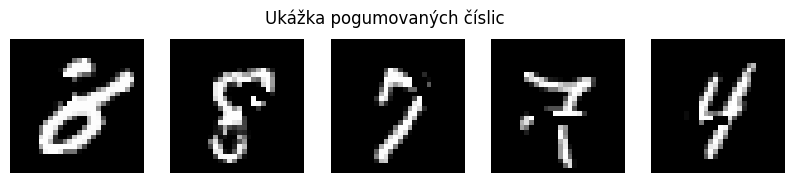

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])


mnist_train_raw = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test_raw = datasets.MNIST(root='./data', train=False, download=True, transform=transform)



100%|██████████| 9.91M/9.91M [00:10<00:00, 948kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 95.9kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.06MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 22.5MB/s]


In [ ]:
def bezier_curve(p0, p1, p2, p3, n_points=100):
    """Vypočíta body pre kubickú krivku."""
    t = np.linspace(0, 1, n_points)
    curve = (1-t)**3 * p0[:, None] + \
            3 * (1-t)**2 * t * p1[:, None] + \
            3 * (1-t) * t**2 * p2[:, None] + \
            t**3 * p3[:, None]
    return curve.T

In [ ]:
def erase_with_bezier(img_tensor, thickness=3):
    """Vezme obrázok a 'vygumuje' v ňom náhodnú čiaru."""
    img = img_tensor.clone().squeeze().numpy()
    h, w = img.shape
    
    # Náhodné body
    p0 = np.array([np.random.randint(-5, w+5), np.random.randint(-5, h+5)]) # Začiatok
    p3 = np.array([np.random.randint(-5, w+5), np.random.randint(-5, h+5)]) # Koniec
    p1 = np.array([np.random.randint(-10, w+10), np.random.randint(-10, h+10)]) # Zakrivenie 1
    p2 = np.array([np.random.randint(-10, w+10), np.random.randint(-10, h+10)]) # Zakrivenie 2

    # Výpočet bodov čiary
    curve_points = bezier_curve(p0, p1, p2, p3, n_points=60)

    # Kreslenie čiernou (hodnota 0.0)
    for x, y in curve_points:
        x, y = int(x), int(y)
        r_min_y, r_max_y = max(0, y-thickness), min(h, y+thickness)
        r_min_x, r_max_x = max(0, x-thickness), min(w, x+thickness)
        img[r_min_y:r_max_y, r_min_x:r_max_x] = 0.0

    return torch.from_numpy(img).unsqueeze(0).float()